# VBZ Geo-Map — GeoPandas

Statische Kartenvisualisierung mit **GeoPandas + Matplotlib**.
Ideal für PDF/SVG-Export und publikationsreife Karten.

---

## Architektur-Notizen

**Stärken:**
- `LineCollection` rendert tausende farbige Segmente in einem Objekt — kein Trace-Limit
- Einzige Library mit sauberem PDF/SVG-Vektorexport
- Volle Kontrolle über Layout, Schriften, Farben

**Einschränkungen:**
- Keine Interaktivität (kein Hover, kein Zoom)
- Nicht für Dashboards geeignet

**Empfehlung:** Für finale Report-Karten und Publikationen.


In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
from scipy.spatial import cKDTree
from pathlib import Path

warnings.filterwarnings('ignore')

for _p in [Path.cwd()] + list(Path.cwd().parents):
    if (_p / 'data' / 'interim').exists():
        _ROOT = _p
        break

GTFS_DIR = _ROOT / 'data' / 'interim' / 'vbz' / 'gtfs'
GEO_DIR  = _ROOT / 'data' / 'raw' / 'vbz' / 'stadtkreise' / 'data'

routes = pd.read_parquet(GTFS_DIR / 'gtfs_tram_routes.parquet')
stops  = pd.read_parquet(GTFS_DIR / 'gtfs_tram_stops.parquet')
shapes = pd.read_parquet(GTFS_DIR / 'gtfs_tram_shapes.parquet')
trips  = pd.read_parquet(GTFS_DIR / 'gtfs_tram_trips.parquet')

routes_2024  = routes[routes['year'] == '2024'].copy()
shapes_2024  = shapes[shapes['year'] == '2024'].copy()
stops_2024   = stops[stops['year'] == '2024'].copy()
trips_2024   = trips[trips['year'] == '2024'].copy()
stops_unique = stops_2024.drop_duplicates(subset=['stop_name']).copy()

np.random.seed(42)
stops_unique['delay_min'] = np.random.exponential(scale=1.5, size=len(stops_unique)).round(1)

gdf_stops  = gpd.GeoDataFrame(stops_unique,
    geometry=gpd.points_from_xy(stops_unique['stop_lon'], stops_unique['stop_lat']),
    crs='EPSG:4326')
gdf_kreise = gpd.read_file(GEO_DIR / 'stzh_adm_stadtkreise_v.json')
gdf_labels = gpd.read_file(GEO_DIR / 'stzh_adm_stadtkreise_beschr_p.json')

kreis_map = {str(r['objid']): r['kname'] for _, r in gdf_kreise.iterrows()}
gdf_labels['kname'] = gdf_labels['objid'].astype(str).map(kreis_map)

line_colors = dict(zip(routes_2024['route_short_name'], '#' + routes_2024['route_color']))

def best_shape_for_line(line_name):
    route_ids = routes_2024[routes_2024['route_short_name'] == line_name]['route_id']
    shape_ids = trips_2024[trips_2024['route_id'].isin(route_ids)]['shape_id'].unique()
    if len(shape_ids) == 0:
        return None
    return max(shape_ids, key=lambda s: len(shapes_2024[shapes_2024['shape_id'] == s]))

print(f'Stadtkreise: {len(gdf_kreise)}  Stops: {len(gdf_stops)}')

for _p in [Path.cwd()] + list(Path.cwd().parents):
    if (_p / 'reports').exists():
        REPORTS_DIR = _p / 'reports'
        break
REPORTS_DIR.mkdir(exist_ok=True)


Stadtkreise: 12  Stops: 1189


## Karte 1 — Stadtkreise + Tramnetz + Haltestellen


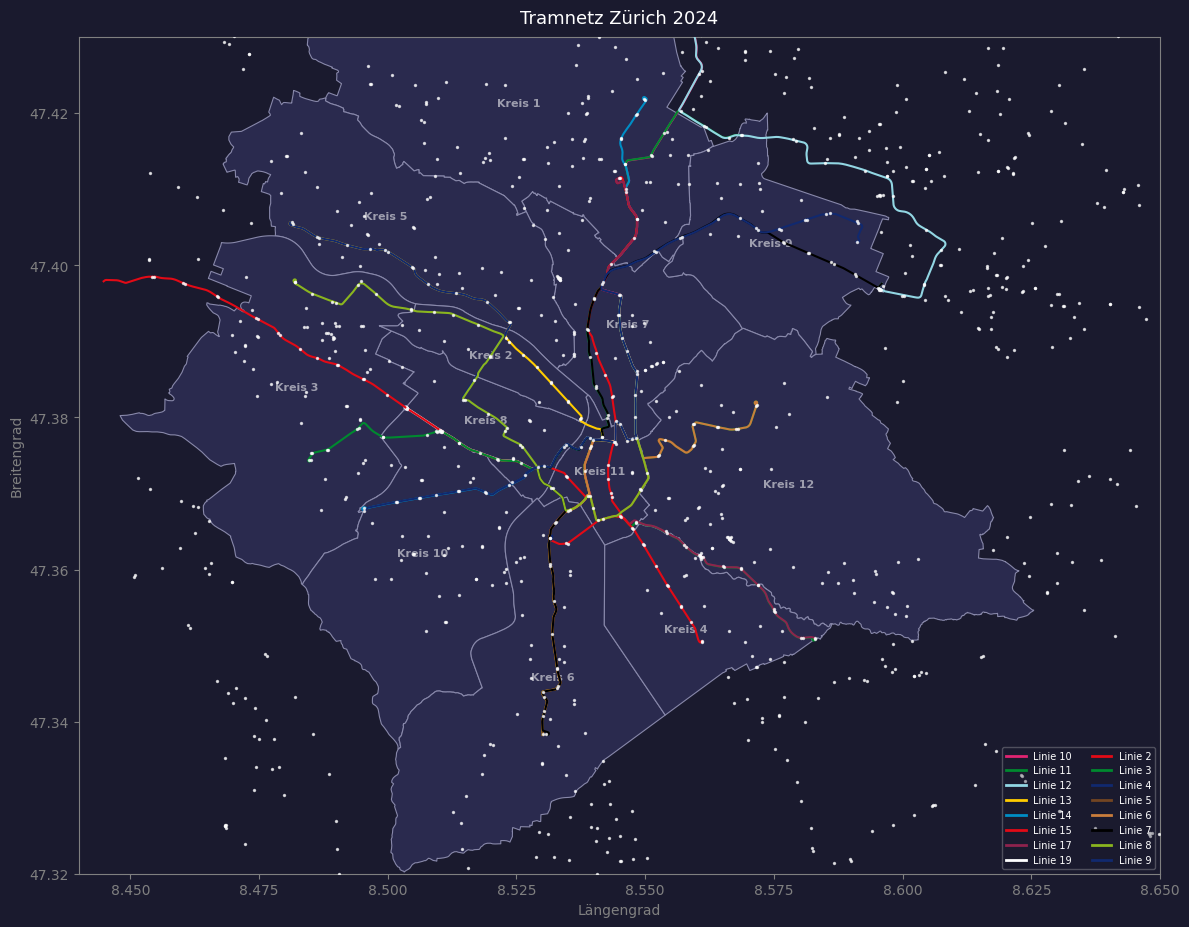

In [2]:
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

gdf_kreise.plot(ax=ax, color='#2a2a4e', edgecolor='#8888aa', linewidth=0.8)

for _, row in gdf_labels.iterrows():
    if row['kname']:
        ax.annotate(row['kname'], xy=(row.geometry.x, row.geometry.y),
            ha='center', va='center', fontsize=8,
            color='white', alpha=0.55, fontweight='bold')

legend_handles = []
for line in sorted(routes_2024['route_short_name'].unique()):
    color    = line_colors.get(line, '#999999')
    shape_id = best_shape_for_line(line)
    if shape_id is None:
        continue
    pts = shapes_2024[shapes_2024['shape_id'] == shape_id].sort_values('shape_pt_sequence')
    ax.plot(pts['shape_pt_lon'].values, pts['shape_pt_lat'].values,
            color=color, linewidth=1.5, zorder=3)
    legend_handles.append(Line2D([0], [0], color=color, linewidth=2, label=f'Linie {line}'))

gdf_stops.plot(ax=ax, color='white', markersize=2, zorder=4, alpha=0.7)

ax.set_xlim(8.44, 8.65)
ax.set_ylim(47.32, 47.43)
ax.set_title('Tramnetz Zürich 2024', color='white', fontsize=13, pad=10)
ax.tick_params(colors='gray')
ax.set_xlabel('Längengrad', color='gray')
ax.set_ylabel('Breitengrad', color='gray')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')

ax.legend(handles=legend_handles, loc='lower right', fontsize=7, ncol=2,
          framealpha=0.3, labelcolor='white', facecolor='#1a1a2e')

plt.tight_layout()
plt.savefig(REPORTS_DIR / "geopandas_tramnetz.pdf", bbox_inches="tight", dpi=150)
plt.show()


## Karte 2 — Verspätungs-Heatmap


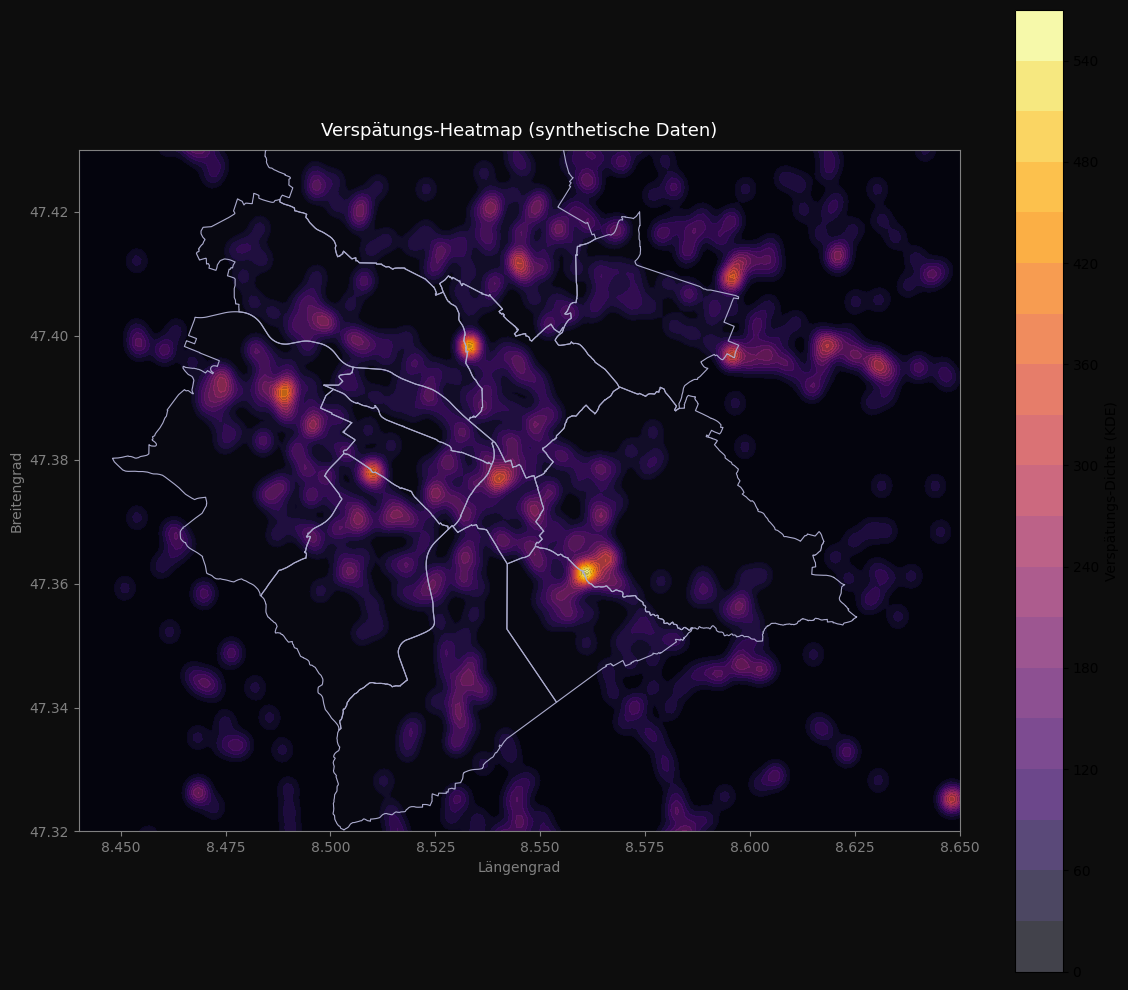

In [3]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor('#0d0d0d')
fig.patch.set_facecolor('#0d0d0d')

gdf_kreise.plot(ax=ax, color='#1a1a1a', edgecolor='#444444', linewidth=0.8)

lons    = stops_unique['stop_lon'].values
lats    = stops_unique['stop_lat'].values
weights = stops_unique['delay_min'].values

rng = np.random.default_rng(42)
idx = rng.choice(len(lons), size=min(800, len(lons)), replace=False,
                 p=weights / weights.sum())

grid_lons = np.linspace(8.44, 8.65, 200)
grid_lats = np.linspace(47.32, 47.43, 200)
X, Y = np.meshgrid(grid_lons, grid_lats)

kde = gaussian_kde(np.vstack([lons[idx], lats[idx]]), bw_method=0.04)
Z   = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

heat = ax.contourf(X, Y, Z, levels=20, cmap='inferno', alpha=0.75, zorder=2)
plt.colorbar(heat, ax=ax, label='Verspätungs-Dichte (KDE)')

gdf_kreise.boundary.plot(ax=ax, color='#aaaacc', linewidth=0.8, zorder=3)

ax.set_xlim(8.44, 8.65)
ax.set_ylim(47.32, 47.43)
ax.set_title('Verspätungs-Heatmap (synthetische Daten)', color='white', fontsize=13, pad=10)
ax.tick_params(colors='gray')
ax.set_xlabel('Längengrad', color='gray')
ax.set_ylabel('Breitengrad', color='gray')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')

plt.tight_layout()
plt.savefig(REPORTS_DIR / "geopandas_heatmap.pdf", bbox_inches="tight", dpi=150)
plt.show()


## Karte 3 — Verspätung auf Streckenabschnitten

> Linie 11 als Beispiel. `LineCollection` rendert alle Segmente in einem Objekt — kein Performance-Problem.


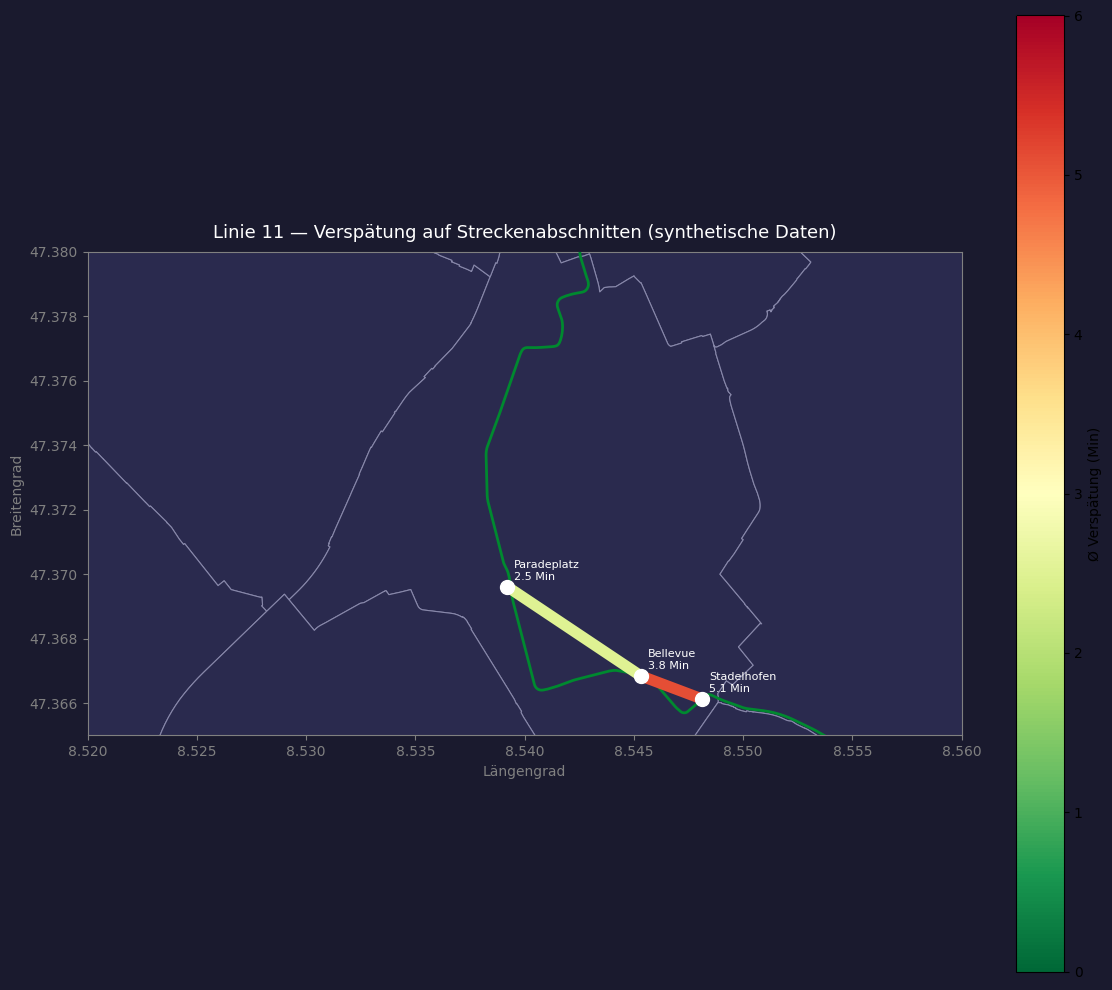

In [4]:
stops_2024_local = stops[stops['year'] == '2024'].copy()

h1 = stops_2024_local[stops_2024_local['stop_name'] == 'Zürich, Paradeplatz'].iloc[0]
h2 = stops_2024_local[stops_2024_local['stop_name'] == 'Zürich, Bellevue'].iloc[0]
h3 = stops_2024_local[stops_2024_local['stop_name'] == 'Zürich, Bahnhof Stadelhofen'].iloc[0]

route_ids_11 = routes_2024[routes_2024['route_short_name'] == '11']['route_id']
shape_ids_11 = trips_2024[trips_2024['route_id'].isin(route_ids_11)]['shape_id'].unique()
shape_id_11  = max(shape_ids_11, key=lambda s: len(shapes_2024[shapes_2024['shape_id'] == s]))
shape_11     = shapes_2024[shapes_2024['shape_id'] == shape_id_11].sort_values('shape_pt_sequence')
color_11     = '#' + routes_2024[routes_2024['route_short_name'] == '11']['route_color'].iloc[0]

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

gdf_kreise.plot(ax=ax, color='#2a2a4e', edgecolor='#8888aa', linewidth=0.8)

# Linie 11 in VBZ-Farbe
ax.plot(shape_11['shape_pt_lon'].values, shape_11['shape_pt_lat'].values,
        color=color_11, linewidth=2, zorder=3)

# Segmente als LineCollection
segments = [
    [(h1['stop_lon'], h1['stop_lat']), (h2['stop_lon'], h2['stop_lat'])],
    [(h2['stop_lon'], h2['stop_lat']), (h3['stop_lon'], h3['stop_lat'])],
]
delays = [2.5, 5.1]

norm = mcolors.Normalize(vmin=0, vmax=6)
lc   = LineCollection(segments, array=np.array(delays),
                      cmap='RdYlGn_r', norm=norm, linewidth=8, zorder=4)
ax.add_collection(lc)
plt.colorbar(lc, ax=ax, label='Ø Verspätung (Min)')

# Haltestellen
for h, name, delay in [(h1, 'Paradeplatz', 2.5), (h2, 'Bellevue', 3.8), (h3, 'Stadelhofen', 5.1)]:
    ax.scatter(h['stop_lon'], h['stop_lat'], s=100, color='white', zorder=5)
    ax.annotate(f'{name}\n{delay} Min', xy=(h['stop_lon'], h['stop_lat']),
                xytext=(5, 5), textcoords='offset points',
                color='white', fontsize=8)

ax.set_xlim(8.52, 8.56)
ax.set_ylim(47.365, 47.380)
ax.set_title('Linie 11 — Verspätung auf Streckenabschnitten (synthetische Daten)',
             color='white', fontsize=13, pad=10)
ax.tick_params(colors='gray')
ax.set_xlabel('Längengrad', color='gray')
ax.set_ylabel('Breitengrad', color='gray')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')

plt.tight_layout()
plt.savefig(REPORTS_DIR / "geopandas_strecken_linie11.pdf", bbox_inches="tight", dpi=150)
plt.show()
